In [ ]:
from face_score import FACEScorer
from data_utils import load_text_data
from tqdm import tqdm
import torch
import pandas as pd
import re

# model_path = '/data1/model/pythia-410m-base'
model_path = '/data1/model/llama3_1-8b-base'
scorer = FACEScorer(model_path, device='cuda:0,1')

/home/lxq/anaconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-03-14 14:02:56.294321: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741960976.307904 1719237 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741960976.311985 1719237 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-14 14:02:56.328354: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critic

In [3]:
def test_pythia_nll(text_file,save_dir="/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-a-nll.txt"):
    texts = load_text_data(text_file)
    pack = scorer.texts_to_nll_with_tokens(texts)
    
    # process tokens and words
    # if further one word nll is needed
    nll_all = []
    for i in range(len(pack)):
        words = texts[i].split()
        tokens = pack[i]['tokens']
        # print("tokens",tokens)
        # print("words",words)
        nlls = pack[i]['nll']
        nll_list = []
        # remove special characters and leading space
        tokens = [re.sub(r'[^\w\s]', '', token.lstrip('Ġ')) for token in tokens]
        # remove the last token if it is a 'Ċ'
        tokens = tokens[:-1] if tokens[-1] == 'Ċ' else tokens
        words = [re.sub(r'[^\w\s]', '', word) for word in words]
        # remove empty string
        tokens = [token for token in tokens if token.strip()]
        words = [word for word in words if word.strip()]
        
        # remove the first word
        words = words[1:]
        token_index = 0
        for i in range(len(words)):
            # print("i",i)
            # print("words[i]",words[i])
            
            temp = tokens[token_index]
            nll_plus = nlls[token_index]
            while temp not in words[i]:
                print("temp not in words[i]",temp,words[i])
                token_index += 1
                temp = tokens[token_index]
            while temp != words[i]:
                temp += tokens[token_index+1]
                token_index += 1
                nll_plus += nlls[token_index]
            nll_list.append((words[i],nll_plus))
            # nll_list.append({'word':words[i],'nll':nll_plus,})
            token_index += 1
        nll_all.append(nll_list)  
    # pack = [{'nll':nll,'tokens':tokens} for nll,tokens in pack]
    # pd.DataFrame(pack).to_csv(save_dir,header=None,index=None)
    
    # sum of nll
    nlls_sum = [sum(nll['nll']) for nll in pack]
    pd.DataFrame(nlls_sum).to_csv(save_dir,header=None,index=None)
    return nll_all

nlls_a = test_pythia_nll("/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-a.txt","/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-a-nll.txt")
nlls_b = test_pythia_nll("/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-b.txt","/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-b-nll.txt")
pd.DataFrame(nlls_a).to_csv("/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-a-nlls.txt",header=None,index=None)
pd.DataFrame(nlls_b).to_csv("/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-b-nlls.txt",header=None,index=None)
# test_pythia_nll("/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-b.txt","/home/lxq/proj/eye-track/manipulation/metrics/mt_exp_dataset/nll/nll_FACEScore/mt-bench-b-nll.txt")

100%|██████████| 14/14 [00:05<00:00,  2.51it/s]


temp not in words[i] m sorry
temp not in words[i] âĢľ xxx
temp not in words[i] âĢĿ which
temp not in words[i] âĢľ Gradually
temp not in words[i] PT Please
temp not in words[i] 4 Please
temp not in words[i] PT Please
temp not in words[i] 4 Please
temp not in words[i] PT Please
temp not in words[i] 4 Please
temp not in words[i] AVIS has
temp not in words[i] AVIS has
temp not in words[i] ocrates employed
temp not in words[i] ocrates employed


100%|██████████| 14/14 [00:05<00:00,  2.44it/s]

temp not in words[i] AVIS has
temp not in words[i] AVIS has
temp not in words[i] PT Please
temp not in words[i] 4 Please
temp not in words[i] ocrates employed
temp not in words[i] ocrates employed


相关性矩阵：
          X1        X2        X3
X1  1.000000  0.872404 -0.081538
X2  0.872404  1.000000 -0.396741
X3 -0.081538 -0.396741  1.000000


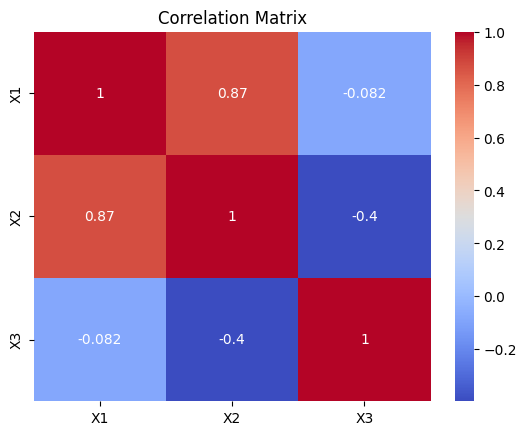

R^2: 0.4504
MSE: 1.1214


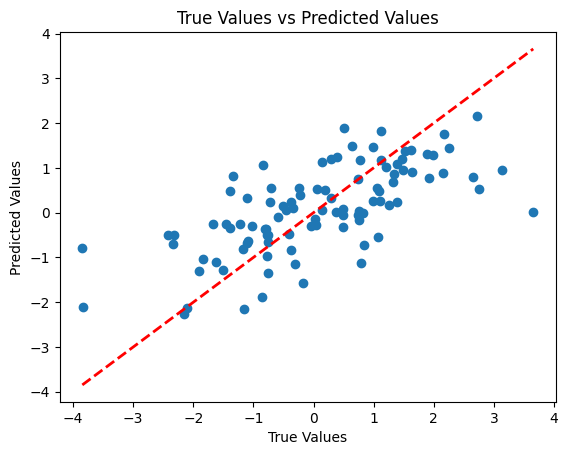

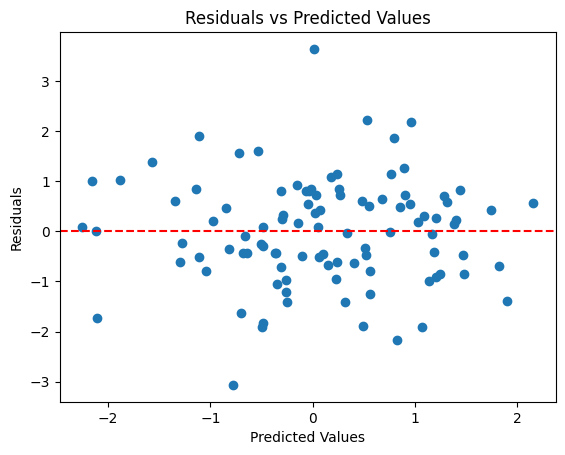

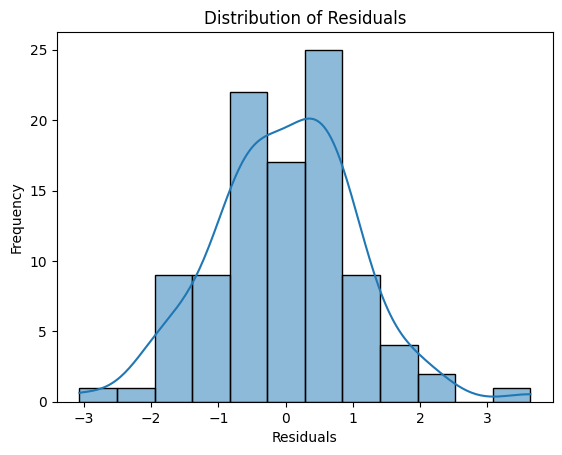

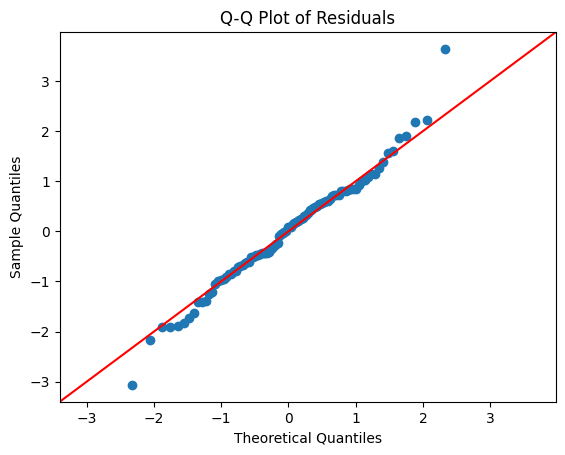